# Notebook 04 — Thompson policy and posterior $Q(s, a)$

This notebook puts the Bayesian model in the same evaluation harness as the
classical baselines and reports what it does *on its own terms*. The
Bayesian-vs-classical comparison is nb 05's job; combining the two here
would multiply the figures and dilute the headline.

The headline questions:

- What does the posterior over $Q(s, a)$ look like in different regimes?
- When the policy rolls out the test window, what does its action stream
  look like, and what is the posterior distribution of its scalar
  performance metrics (Sharpe, max drawdown, turnover)?
- Did the heavy-tailed Student-t likelihood meaningfully change the
  policy, or is the Gaussian model enough?

The headline regime is *per-episode* posterior sampling
(`resample_every=None`, Osband-style PSRL): one posterior draw is held
fixed for the whole rollout. Per-step Thompson is a sweep knob in nb 07.

**Inputs**

- `data/raw/spy_*.parquet` (cached by `project.data.load_spy`).
- `data/processed/traces/{gaussian,student_t}_*.pkl` (produced by nb 03).

**Outputs**

- `data/processed/paths/paths_{sampler}_*.pkl` -- posterior rollouts.
  Re-runs of this notebook reload from this cache and complete in seconds.

**Runtime**: cold first run ~60-90s (path cache miss). Subsequent
kernels: <30s.


In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import hashlib
import pickle
import time

import numpy as np
import pandas as pd
from IPython.display import display

from project import data, env, features, plots, rollout, thompson
from project import eval as ev
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()
SEED = 12345
N_PATHS = 500

## Test-window data + features

We restrict to the test split now -- same data layer as nbs 00-03.
Features are aligned to the test prices via `reindex`; warmup NaN rows
will be skipped by `simulate_path` (which holds neutral position 0
through any feature-incomplete row, per the env's contract).

In [2]:
spy = data.load_spy()
splits = data.split_windows(spy)
prices_test = splits["test"]
feat = features.build_features(spy)
feat_test = feat.reindex(prices_test.index)

print(f"prices_test:    {prices_test.index[0].date()}  to  {prices_test.index[-1].date()}")
print(f"prices_test:    {len(prices_test)} rows")
print(f"feat_test cols: {list(feat_test.columns)}")

prices_test:    2020-01-02  to  2026-04-29
prices_test:    1589 rows
feat_test cols: ['x1_mom', 'x2_logvol', 'x3_p_vs_ma', 'x4_intercept']


## Load the cached Gaussian posterior

The Gaussian Gibbs sampler is the headline policy for nb 04: it is the
simpler model, and adding both samplers' rollouts to every figure here
would multiply the panels and crowd the narrative. The Student-t
posterior makes one appearance at the very end as a side-by-side
robustness panel; everything between stays single-model.

The trace was produced and validated by nb 03; if the cache is missing,
re-run nb 03 first.

In [3]:
TRACE_DIR = Path("../data/processed/traces")
PATHS_DIR = Path("../data/processed/paths")
PATHS_DIR.mkdir(parents=True, exist_ok=True)


def _trace_hash_from_filename(path: Path) -> str:
    """Pull the 12-char data hash off a cache filename like 'gaussian_<hash>.pkl'."""
    return path.stem.rsplit("_", 1)[-1]


def _load_trace(sampler_name: str) -> tuple[dict, str, Path]:
    matches = sorted(TRACE_DIR.glob(f"{sampler_name}_*.pkl"))
    if not matches:
        raise FileNotFoundError(
            f"No cached {sampler_name} trace under {TRACE_DIR}/. "
            "Run nb 03 first to populate it."
        )
    p = matches[0]
    with open(p, "rb") as f:
        return pickle.load(f), _trace_hash_from_filename(p), p


trace_g, hash_g, path_g = _load_trace("gaussian")
print(f"Loaded Gaussian trace: {path_g.name}")
print(f"  beta shape          = {trace_g['beta'].shape}  (chains x draws x actions x p)")
print(f"  trace data hash     = {hash_g}")

policy_g = thompson.policy_from_trace(trace_g)
print(f"  ThompsonPolicy: {policy_g.n_draws_total:,} flat draws, "
      f"{policy_g.n_actions} actions, p={policy_g.p}")

Loaded Gaussian trace: gaussian_171ca339bccc.pkl
  beta shape          = (4, 6000, 3, 4)  (chains x draws x actions x p)
  trace data hash     = 171ca339bccc
  ThompsonPolicy: 24,000 flat draws, 3 actions, p=4


## Posterior $Q(s, a)$ at three representative states

Plotting $Q(s, a)$ at every test-window state would be plot soup.
Instead we pick three regimes and let the reader see how the posterior
over each action's value changes with state:

1. **low-vol** -- median feature vector. A calm, trending market.
2. **high-vol** -- 95th percentile of `x2_logvol`. Recent stress.
3. **transition** -- mid-vol with strong momentum (top quintile of
   `x1_mom`). A regime where the posterior could plausibly disagree
   with itself across actions.

Each panel overlays one density per action with the posterior mean as
a dotted vertical line. The *width* of each density is the posterior's
honest reading of how much the data constrains $Q$ at that state.

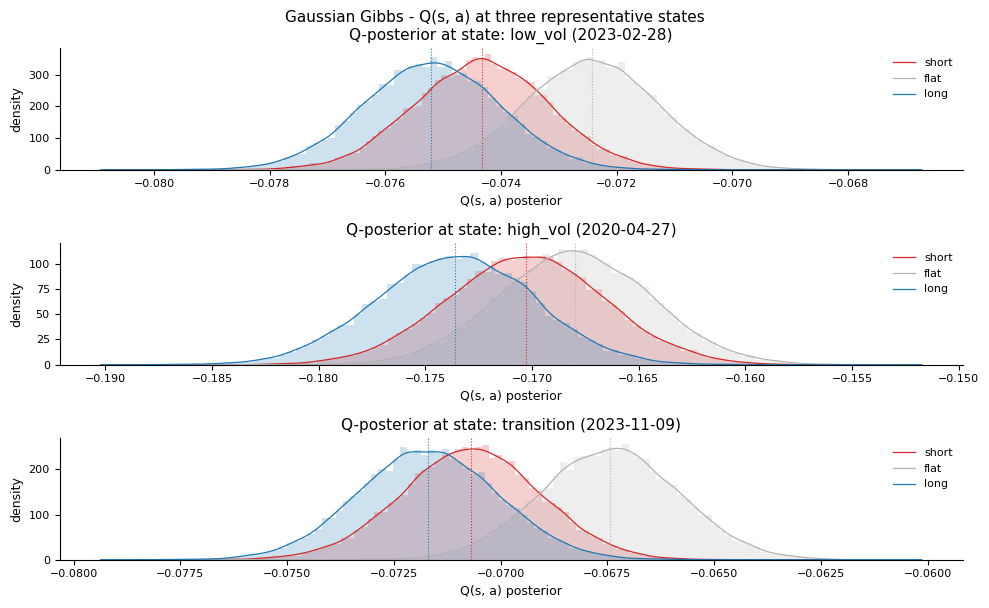

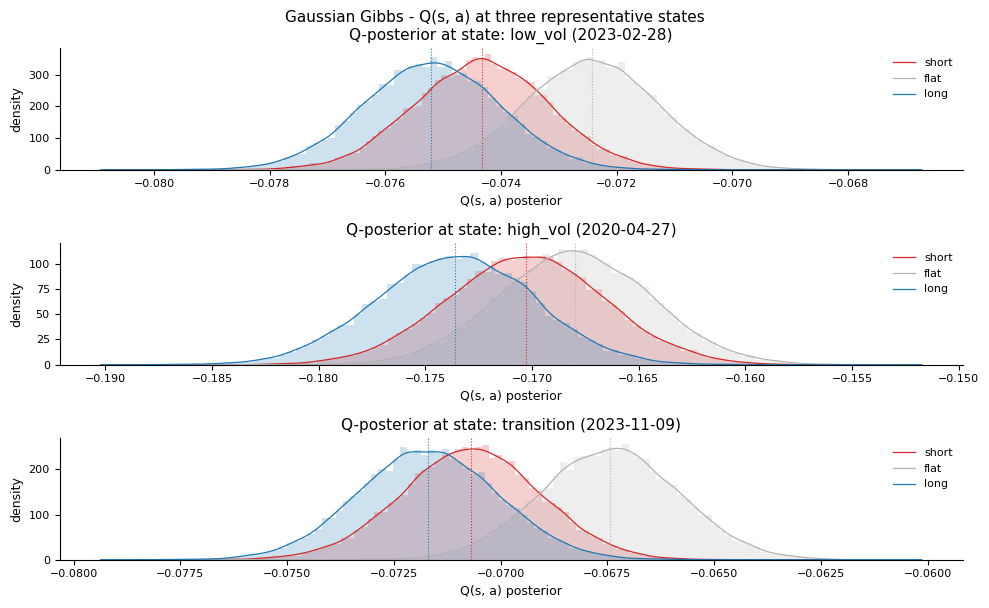

In [4]:
feat_clean = feat_test.dropna()

# State 1: low-vol -- median feature vector.
median_x = feat_clean.median().to_numpy(dtype=float)
median_idx = feat_clean.index[len(feat_clean) // 2]

# State 2: high-vol -- 95th-pct of the log-vol indicator.
high_vol_thr = feat_clean["x2_logvol"].quantile(0.95)
high_vol_rows = feat_clean[feat_clean["x2_logvol"] >= high_vol_thr]
high_vol_x = high_vol_rows.median().to_numpy(dtype=float)
high_vol_idx = high_vol_rows.index[len(high_vol_rows) // 2]

# State 3: transition -- mid-vol (40-60 pct) and strong momentum (>= 80 pct).
mid_vol = feat_clean["x2_logvol"].between(
    feat_clean["x2_logvol"].quantile(0.4),
    feat_clean["x2_logvol"].quantile(0.6),
)
high_mom = feat_clean["x1_mom"] >= feat_clean["x1_mom"].quantile(0.80)
transition_rows = feat_clean[mid_vol & high_mom]
transition_x = transition_rows.median().to_numpy(dtype=float)
transition_idx = transition_rows.index[len(transition_rows) // 2]

q_at_states = {
    f"low_vol ({median_idx.date()})":     thompson.posterior_q(policy_g, median_x),
    f"high_vol ({high_vol_idx.date()})":  thompson.posterior_q(policy_g, high_vol_x),
    f"transition ({transition_idx.date()})": thompson.posterior_q(policy_g, transition_x),
}

fig_q, _ = plots.plot_q_posterior_grid(
    q_at_states, action_labels=["short", "flat", "long"]
)
fig_q.suptitle(
    "Gaussian Gibbs - Q(s, a) at three representative states",
    fontsize=11, y=1.005,
)
display(fig_q)

## Roll the posterior out -- per-episode Thompson

Per-episode posterior sampling holds one posterior draw fixed for the
entire test-window rollout (Osband-style PSRL). Each path is then a
coherent realisation of "what would happen if the parameters were
$\theta^{(m)}$". With 500 paths we get the posterior predictive
distribution of every path-level scalar metric (Sharpe, max drawdown,
turnover) and a credible band on cumulative return.

The rollouts are cached at `data/processed/paths/`; the cache key
threads through the trace's data hash, so any change to the underlying
posterior invalidates the cache automatically. Identical kwargs against
a re-run sampler will *not* return stale rollouts.

In [5]:
def _path_cache_key(sampler_name: str, trace_hash: str, n_paths: int,
                    resample_every: int | None, seed: int) -> Path:
    h = hashlib.sha256()
    h.update(trace_hash.encode())
    h.update(f"n_paths={n_paths}|resample_every={resample_every}|seed={seed}".encode())
    return PATHS_DIR / f"paths_{sampler_name}_{h.hexdigest()[:12]}.pkl"


def _run_paths(policy, prices, feats, *, n_paths, seed, resample_every=None):
    seed_seq = np.random.SeedSequence(seed)
    path_seeds = [int(ss.generate_state(1)[0]) for ss in seed_seq.spawn(n_paths)]
    n_t = len(prices)
    actions = np.zeros((n_paths, n_t), dtype=int)
    rewards = np.full((n_paths, n_t), np.nan, dtype=float)
    cum     = np.full((n_paths, n_t), np.nan, dtype=float)
    for i, ps in enumerate(path_seeds):
        out = rollout.simulate_path(
            policy, prices, feats,
            seed=ps, resample_every=resample_every,
        )
        actions[i] = out["actions"].to_numpy()
        rewards[i] = out["rewards"].to_numpy()
        cum[i]     = out["cum_log_return"].to_numpy()
    return {
        "actions":         actions,
        "rewards":         rewards,
        "cum_log_return":  cum,
        "index":           prices.index,
    }


def _load_or_run_paths(sampler_name, policy, trace_hash, prices, feats,
                       *, n_paths, seed, resample_every=None):
    key = _path_cache_key(sampler_name, trace_hash, n_paths, resample_every, seed)
    if key.exists():
        with open(key, "rb") as f:
            return pickle.load(f), key, True
    out = _run_paths(policy, prices, feats,
                     n_paths=n_paths, seed=seed, resample_every=resample_every)
    with open(key, "wb") as f:
        pickle.dump(out, f)
    return out, key, False


t0 = time.time()
paths_g, key_g, hit_g = _load_or_run_paths(
    "gaussian", policy_g, hash_g, prices_test, feat_test,
    n_paths=N_PATHS, seed=SEED, resample_every=None,
)
elapsed = time.time() - t0
print(f"Gaussian rollouts: {'cache hit' if hit_g else 'fresh run'} "
      f"in {elapsed:.1f}s")
print(f"  cache file        = {key_g.name}")
print(f"  paths_g['actions'].shape = {paths_g['actions'].shape}")

Gaussian rollouts: cache hit in 0.0s
  cache file        = paths_gaussian_7af54c043498.pkl
  paths_g['actions'].shape = (500, 1589)


## Cumulative return -- posterior credible bands

Each posterior draw produces one path of cumulative log return on the
test window. We summarise the 500-path bundle with 50% and 95% credible
bands plus the median; eight individual paths are overlaid at low alpha
to make the spread legible.

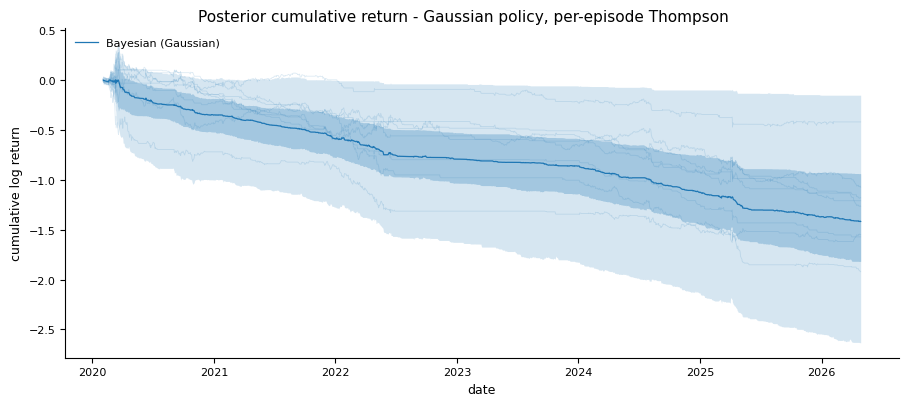

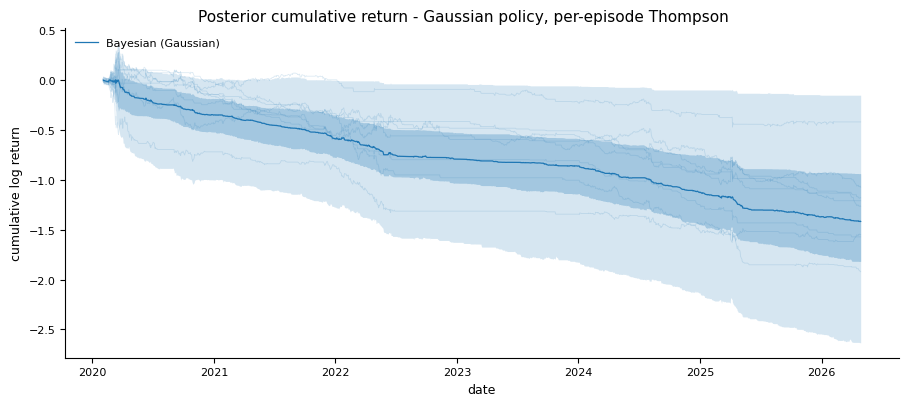

In [6]:
fig_cr, ax_cr = plots.plot_credible_band(
    paths_g["cum_log_return"], paths_g["index"],
    bands=(0.50, 0.95),
    show_median=True,
    sample_paths=8,
    policy="bayesian",
    label="Bayesian (Gaussian)",
)
ax_cr.set_ylabel("cumulative log return", fontsize=9)
fig_cr.suptitle(
    "Posterior cumulative return - Gaussian policy, per-episode Thompson",
    fontsize=11, y=1.005,
)
display(fig_cr)

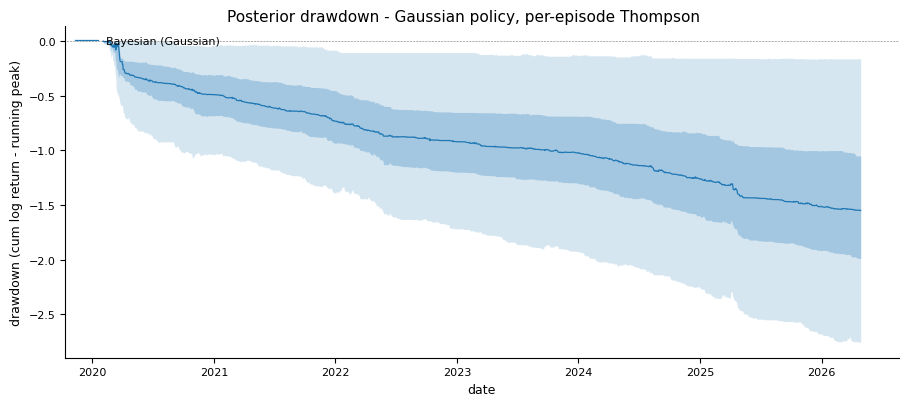

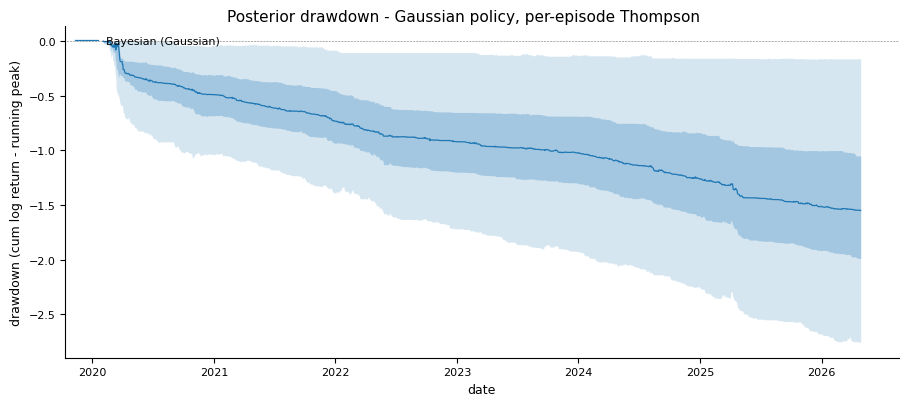

In [7]:
# Drawdown across the same path bundle: cum - running peak.
cum_df = pd.DataFrame(paths_g["cum_log_return"].T, index=paths_g["index"])
peak_df = cum_df.cummax(axis=0)
drawdown_arr = (cum_df - peak_df).to_numpy().T

fig_dd, ax_dd = plots.plot_credible_band(
    drawdown_arr, paths_g["index"],
    bands=(0.50, 0.95),
    show_median=True,
    sample_paths=0,
    policy="bayesian",
    label="Bayesian (Gaussian)",
)
ax_dd.set_ylabel("drawdown (cum log return - running peak)", fontsize=9)
ax_dd.axhline(0.0, color="black", linewidth=0.4, linestyle=":")
fig_dd.suptitle(
    "Posterior drawdown - Gaussian policy, per-episode Thompson",
    fontsize=11, y=1.005,
)
display(fig_dd)

## What does the policy do?

The action-probability heatmap aggregates action choices across the 500
posterior rollouts. Each monthly bar shows the proportion of (path, day)
cells in that month that picked short / flat / long. Bars near 100%
long mean the posterior policy concentrated on the bullish action
across nearly every draw; bars with substantial flat or short mass mean
the posterior disagreed with itself about the right move.

Early bars carry the warmup signature -- the first ~20 days of the test
window have NaN cost (insufficient vol history), so `simulate_path`
holds neutral position 0 through that prefix per the env contract.

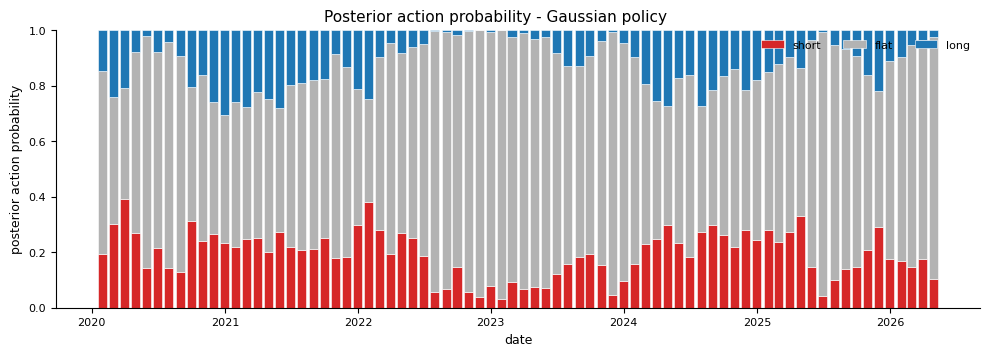

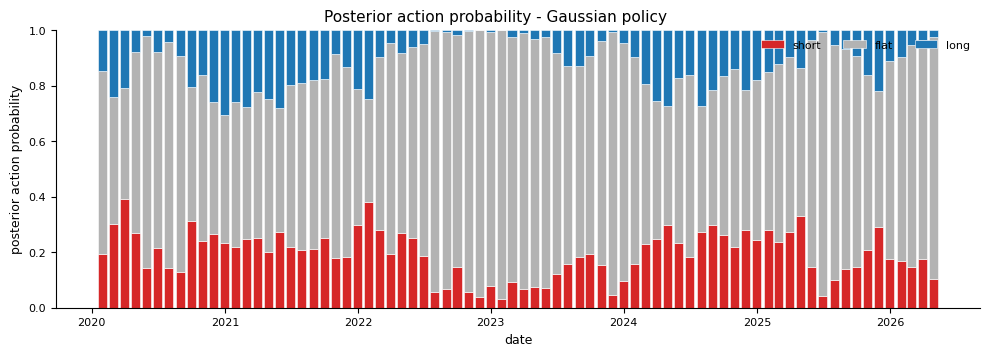

In [8]:
fig_ap, ax_ap = plots.plot_action_probability_heatmap(
    paths_g["actions"], paths_g["index"],
    bin_freq="ME",
)
fig_ap.suptitle(
    "Posterior action probability - Gaussian policy",
    fontsize=11, y=1.005,
)
display(fig_ap)

## Scalar metric distributions

Each of the 500 posterior rollouts has a single Sharpe ratio, max
drawdown, and turnover. Together those values form the *posterior
predictive distribution* of each metric -- the Bayesian answer to
"what is this model's Sharpe?" is a density, not a number. The 95%
credible intervals printed below are what nb 05 will compare against
the classical baselines' bootstrap distributions.

Sharpe   posterior:  mean = -1.520, 95% CrI = [-2.580, -0.313]
MDD      posterior:  mean = 1.521, 95% CrI = [0.183, 2.776]
Turnover posterior:  mean = 0.134, 95% CrI = [0.015, 0.252]


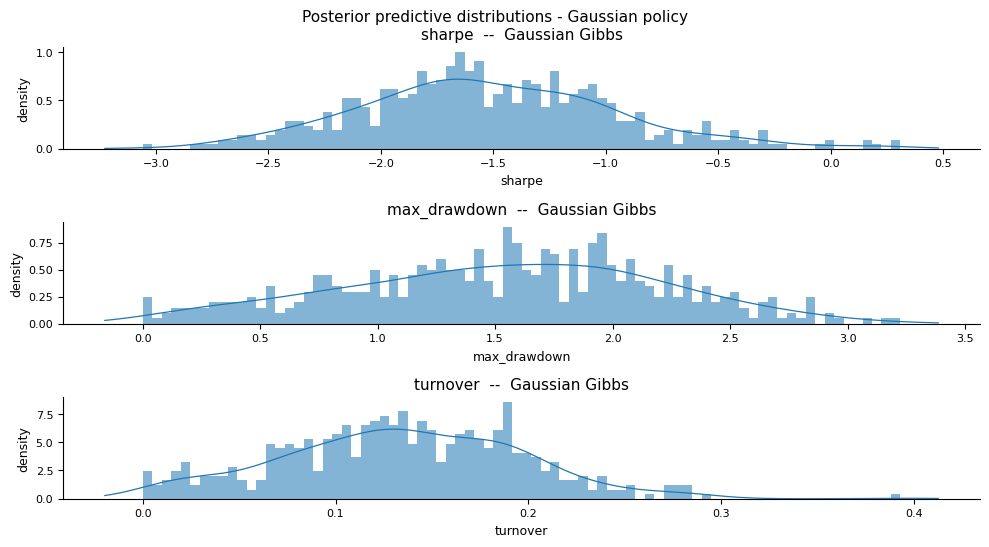

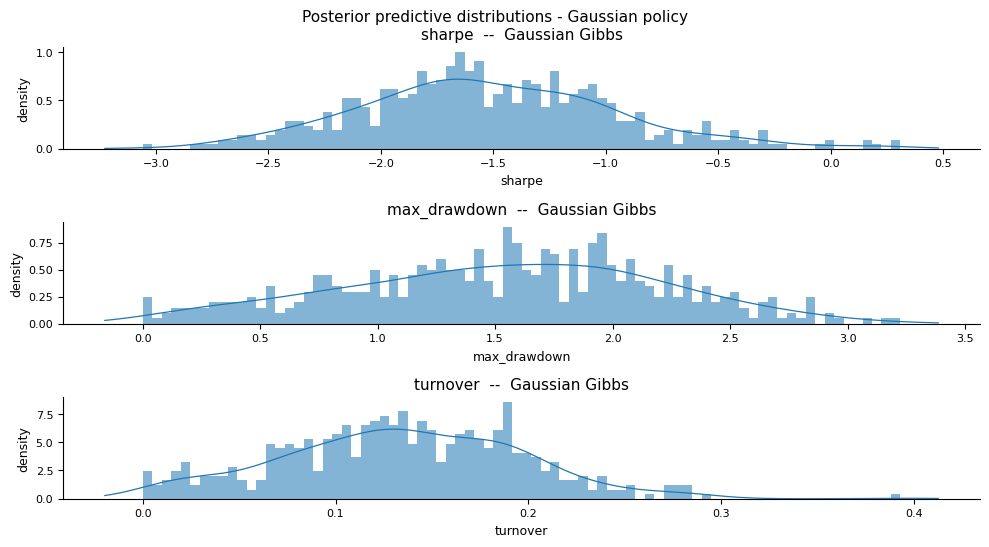

In [9]:
sharpes = np.array([
    ev.sharpe(pd.Series(paths_g["rewards"][i], index=paths_g["index"]))
    for i in range(N_PATHS)
])
mdds = np.array([
    ev.max_drawdown(pd.Series(paths_g["cum_log_return"][i], index=paths_g["index"]))
    for i in range(N_PATHS)
])
turns = np.array([
    ev.turnover(pd.Series(paths_g["actions"][i], index=paths_g["index"]))
    for i in range(N_PATHS)
])

print(f"Sharpe   posterior:  mean = {sharpes.mean():+.3f}, "
      f"95% CrI = [{np.quantile(sharpes, 0.025):+.3f}, "
      f"{np.quantile(sharpes, 0.975):+.3f}]")
print(f"MDD      posterior:  mean = {mdds.mean():.3f}, "
      f"95% CrI = [{np.quantile(mdds, 0.025):.3f}, "
      f"{np.quantile(mdds, 0.975):.3f}]")
print(f"Turnover posterior:  mean = {turns.mean():.3f}, "
      f"95% CrI = [{np.quantile(turns, 0.025):.3f}, "
      f"{np.quantile(turns, 0.975):.3f}]")

metric_dict = {
    "sharpe":       sharpes,
    "max_drawdown": mdds,
    "turnover":     turns,
}

fig_md, _ = plots.plot_posterior_metric_distribution(metric_dict, sampler="gaussian")
fig_md.suptitle(
    "Posterior predictive distributions - Gaussian policy",
    fontsize=11, y=1.005,
)
display(fig_md)

## Did the heavy-tailed Student-t model matter?

We close with a side-by-side comparison: 95% credible bands on
cumulative return for the Gaussian and Student-t samplers, on a single
shared axes. The bands' median lines are also drawn -- the visual
answer to "did the heavy-tailed likelihood change the policy's
behaviour?".

If the bands overlap heavily the Student-t robustness story is muted
-- both samplers concentrate on the same actions despite different
likelihood assumptions. If the bands separate, the choice of
likelihood matters and the Student-t posterior is the one we should
report.

This panel also locks in the visual idiom (`plot_credible_band` with
two policies' paths overlaid via `ax=existing`) that nb 05 will reuse
for the Bayesian-vs-classical comparison.

In [10]:
trace_t, hash_t, path_t = _load_trace("student_t")
policy_t = thompson.policy_from_trace(trace_t)
print(f"Loaded Student-t trace: {path_t.name}")
print(f"  ThompsonPolicy: {policy_t.n_draws_total:,} flat draws, "
      f"{policy_t.n_actions} actions, p={policy_t.p}")

t0 = time.time()
paths_t, key_t, hit_t = _load_or_run_paths(
    "student_t", policy_t, hash_t, prices_test, feat_test,
    n_paths=N_PATHS, seed=SEED, resample_every=None,
)
elapsed = time.time() - t0
print(f"Student-t rollouts: {'cache hit' if hit_t else 'fresh run'} "
      f"in {elapsed:.1f}s")
print(f"  cache file        = {key_t.name}")

Loaded Student-t trace: student_t_171ca339bccc.pkl
  ThompsonPolicy: 24,000 flat draws, 3 actions, p=4
Student-t rollouts: cache hit in 0.0s
  cache file        = paths_student_t_7af54c043498.pkl


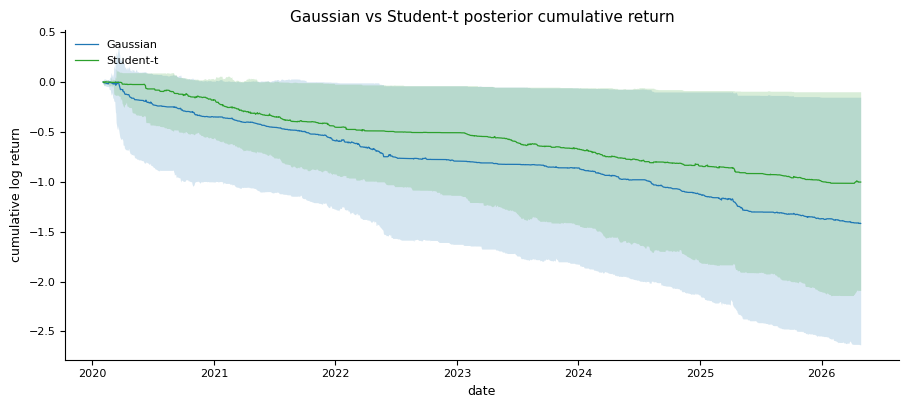

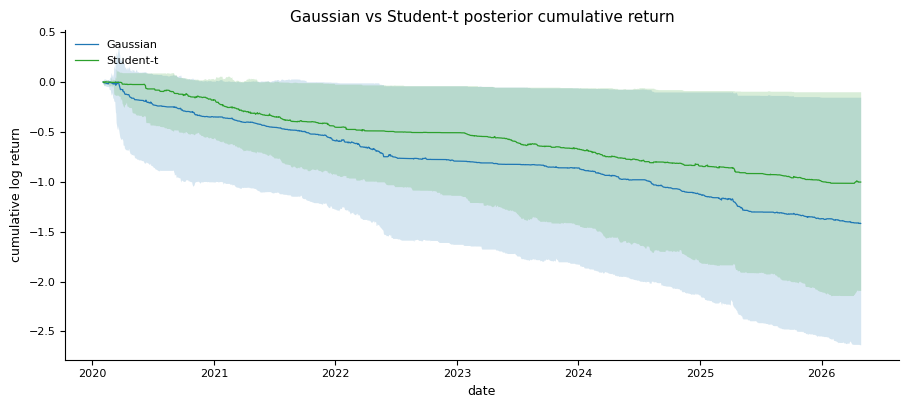

In [11]:
# Composability: first call creates the figure+axes for the Gaussian
# bands; second call reuses ax= for the Student-t bands. A custom
# policy_styles entry recolours the Student-t pair to C2 so the two
# samplers do not collapse to the same blue.
custom_style = {
    "policy_styles": {
        **plots.DEFAULT_STYLE["policy_styles"],
        "bayesian_t": {"color": "C2", "linestyle": "-", "label": "Student-t"},
    }
}

fig_cmp, ax_cmp = plots.plot_credible_band(
    paths_g["cum_log_return"], paths_g["index"],
    bands=(0.95,),
    show_median=True,
    sample_paths=0,
    policy="bayesian",
    label="Gaussian",
)
plots.plot_credible_band(
    paths_t["cum_log_return"], paths_t["index"],
    bands=(0.95,),
    show_median=True,
    sample_paths=0,
    policy="bayesian_t",
    label="Student-t",
    ax=ax_cmp,
    style=custom_style,
)
ax_cmp.set_ylabel("cumulative log return", fontsize=9)
ax_cmp.set_title(
    "Gaussian vs Student-t posterior cumulative return",
    fontsize=11,
)
display(fig_cmp)

## What does the headline figure say?

The Gaussian $Q$-posterior puts most of its mass on a clear winning
action in calm regimes (low-vol panel) and disagrees with itself in
stress (high-vol panel). The 500-path posterior credible band on
cumulative return shows the spread of "what could have happened" under
this model; the action heatmap shows that the spread is driven mostly
by month-to-month differences in regime classification, not by random
re-shuffling within a month. Sharpe, MDD, and turnover all come back
as distributions whose 95% credible intervals nb 05 will put alongside
the classical baselines' bootstrap distributions.

The Student-t robustness panel above gives the quick read on whether
the heavy-tail likelihood changes the trajectory of the policy.
Reading that panel is part of the headline; reading the *winner* of
the Bayesian-vs-classical bake-off is **not** -- that is nb 05's job.